# SO(n): FR guidance via `src/guidance/driver.py` + JacNet projection

Loads the score net (`01_train_score.ipynb`) and JacNet (`02_train_jacnet.ipynb`), runs `basic_fr`'s
Fisher-Rao energy through the shared `driver.guided_reverse_loop` driver but:

- **jacobian** uses JacNet's cheap batched eigendecomposition (top-k smallest-|eigenvalue| directions of
  `M = M_tilde/sigma_t^2`), not per-sample autograd or an analytic ground-truth tangent.
 The eigendecomposition + top-k selection is `driver.make_projector_fn`/`driver.eig_tangent_projector`. When JacNet's
  projector is used, both the energy `I` and its gradient are restricted to the top-k tangent directions by
  construction (`driver.projected_guidance_grad`, computed directly in y-space, no chain through the denoiser).
- **proj_k** (the tangent-dimension knob k, i.e. how many top eigendirections JacNet's projector keeps) is now
  swept over `config["proj_ks"]` 
  Here the true tangent
  dimension of SO(3) (3) isn't known a priori by the projector, so it's a real hyperparameter.
- **energy**: both `basic_fr` and `score_divergence` 

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr, score_divergence, bayesian_fr

score_ckpt = torch.load("checkpoints/score.pt", weights_only=False)
jac_ckpt = torch.load("checkpoints/jacnet.pt", weights_only=False)
score_config = score_ckpt["config"]
jac_config = jac_ckpt["jac_config"]
n, d, device = score_config["n"], score_config["d"], score_config["device"]
X_target = score_ckpt["X_target"].to(device)
print(f"n={n}, d={d}, device={device}, N_data={X_target.shape[0]}")

n=2, d=4, device=cpu, N_data=15


In [2]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

class JacNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d * d)

    def forward(self, z, t):
        h = F.silu(self.input_proj(torch.cat([z, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, score_config["hidden"], score_config["depth"]).to(device)
net.load_state_dict(score_ckpt["net_state"])
net.eval()

jac_net = JacNet(d, jac_config["jac_hidden"], jac_config["jac_depth"]).to(device)
jac_net.load_state_dict(jac_ckpt["jac_net_state"])
jac_net.eval()
print("Loaded score net + JacNet.")

Loaded score net + JacNet.


In [ ]:
config = {
    "n_steps": score_config["n_steps"],
    "n_samples": 100,
    "seed": 1,
    "k_neighbors": 3,
    "r_probes": 4,
    "ell": 1,
    "mem_ratio_threshold": 1 /3,
    "lambdas": [1.0, 50, 100, 500],
    "grad_clips": [1.0, 5, 100, 500],
    "proj_k": 3,     # default k used for the single-trajectory diagnostic below
    "proj_ks": [1, 2, 3],   # tangent-dimension sweep grid for the JacNet projector
}

windows = {
    "throughout": (0.05, 0.9),
    "early": (0.05, 0.25),
    "early_mid": (0.05, 0.5),
    "mid": (0.25, 0.75),
    "mid_late": (0.5, 0.95),
    "late": (0.75, 0.95),
    "very_late": (0.85, 0.95),
    "very_early": (0.05, 0.15)
}

def beta(t):
    return score_config["beta_min"] + t * (score_config["beta_max"] - score_config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(score_config["beta_min"] * t + 0.5 * (score_config["beta_max"] - score_config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1.0 - alpha_bar(t)).clamp(min=1e-6)

def g2(t):
    return beta(t)   # forward SDE's diffusion coefficient squared -- what step_scale_fn needs

## Wire up `driver.py`'s generic interface

In [4]:
n_steps = config["n_steps"]
dt = score_config["T"] / n_steps
t_vec_holder = {"t": None}

def make_base_step_fn():
    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_vec_holder["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5
    return base_step_fn

def y_fn(z_t):
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    a = alpha_bar(t_vec)
    return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()

def step_scale_fn(step_idx):
    # guidance must scale like g(t)^2 * dt, not sigma_t^2 (classifier-guidance/reverse-SDE derivation)
    k = n_steps - step_idx
    t_vec = torch.full((config["n_samples"],), (k + 1) * dt, device=device)
    return g2(t_vec)[:, None] * dt

## Guidance energies: basic_fr and score_divergence, JacNet-based tangent Jacobian

In [5]:
index = basic_fr.build_flat_index(X_target)

def make_knn_energy_fn():
    def energy_fn(y):
        with torch.no_grad():
            neighbors, _ = basic_fr.ann_query(index, y, config["k_neighbors"])
        I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2(t_vec_holder["t"]))
        return I
    return energy_fn

def score_fn(y):
    t_vec = t_vec_holder["t"]
    eps_hat = net(y, t_vec)
    return -eps_hat / sigma2(t_vec)[:, None].sqrt()

def sigma2_fn():
    return sigma2(t_vec_holder["t"])

def d_fn():
    return d

def make_score_divergence_energy_fn():
    return score_divergence.make_score_div_energy_fn(score_fn, sigma2_fn, d_fn, r=config["r_probes"])

ENERGY_FACTORIES = {
    "basic_fr": make_knn_energy_fn,
    "score_divergence": make_score_divergence_energy_fn,
}

# Tangent-projected counterparts: energy_fn(y, P) -> I, restricted to tangent directions by
# construction (see driver.projected_guidance_grad) 
# takes k (num tangent directions) explicitly and builds a fresh energy_fn for it 
def make_knn_projected_energy_fn(k):
    return basic_fr.make_knn_projected_energy_fn(index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]))

def make_score_divergence_projected_energy_fn(k):
    return score_divergence.make_score_div_projected_energy_fn(score_fn, sigma2_fn, k_fn=lambda: k, r=config["r_probes"])

PROJECTED_ENERGY_FACTORIES = {
    "basic_fr": make_knn_projected_energy_fn,
    "score_divergence": make_score_divergence_projected_energy_fn,
}

def jacnet_matrix_fn(y):
    t_vec = t_vec_holder["t"]
    with torch.no_grad():
        M_raw = jac_net(y, t_vec).reshape(y.shape[0], d, d)
        M_tilde = 0.5 * (M_raw + M_raw.transpose(-1, -2))
        return M_tilde / sigma2(t_vec)[:, None, None]

JACOBIAN_NAMES = ["none", "jacnet"]   # "jacnet" is further parameterized by k (config["proj_ks"]) below

def make_guidance_fn(method, jacobian_name, k, grad_clip):
    if jacobian_name == "none":
        energy_fn = ENERGY_FACTORIES[method]()
        return driver.make_autograd_guidance_fn(y_fn, energy_fn, target_range=None, grad_clip=grad_clip)
    projector_fn = driver.make_projector_fn(jacnet_matrix_fn, k=k)
    energy_fn = PROJECTED_ENERGY_FACTORIES[method](k)
    return driver.make_projected_guidance_fn(
        y_fn, energy_fn, projector_fn, target_range=None, grad_clip=grad_clip)

## Diagnostic: raw guidance gradient scale vs `t` (before clipping)

Same check as `toy_manifold/02_fr_guidance.ipynb`: `basic_fr`'s energy divides by `beta_t**2 = sigma_t**4`, so
`I(y)` should blow up as `t -> 0`. Computed along a single unguided trajectory via
`driver.guidance_grad(..., grad_clip=None)` (unprojected, left panel) and
`driver.projected_guidance_grad(..., grad_clip=None)` (projected onto JacNet's tangent estimate at
`k=config["proj_k"]`, right panel), for both energies. Separate panels + separate color sets (blue/orange
unprojected vs. green/red projected) since restricting to tangent directions changes what `I` and its
gradient measure, not just their scale.

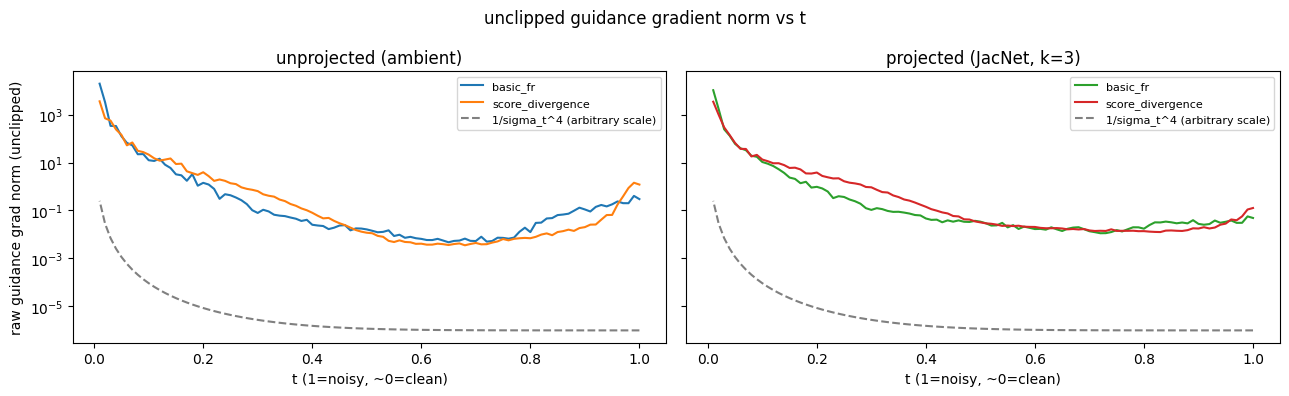

In [6]:
torch.manual_seed(config["seed"])
z = torch.randn(config["n_samples"], d, device=device)
base_step_fn = make_base_step_fn()
diag_energy_fns = {"basic_fr": make_knn_energy_fn(), "score_divergence": make_score_divergence_energy_fn()}
diag_projected_energy_fns = {"basic_fr": make_knn_projected_energy_fn(config["proj_k"]),
                              "score_divergence": make_score_divergence_projected_energy_fn(config["proj_k"])}
diag_projector_fn = driver.make_projector_fn(jacnet_matrix_fn, k=config["proj_k"])

diag_rows = []
for step_idx in range(1, n_steps + 1):
    z_next = base_step_fn(z, step_idx)   # also sets t_vec_holder["t"] for this step
    t_val = t_vec_holder["t"][0].item()
    sigma2_val = sigma2(t_vec_holder["t"])[0].item()
    for name, energy_fn in diag_energy_fns.items():
        grad, _, _ = driver.guidance_grad(y_fn, z, energy_fn, target_range=None, grad_clip=None)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": False,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    for name, energy_fn in diag_projected_energy_fns.items():
        grad, _, _ = driver.projected_guidance_grad(y_fn, z, energy_fn, diag_projector_fn, target_range=None, grad_clip=None)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": True,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    z = z_next

diag_df = pd.DataFrame(diag_rows)

UNPROJ_COLORS = {"basic_fr": "tab:blue", "score_divergence": "tab:orange"}
PROJ_COLORS = {"basic_fr": "tab:green", "score_divergence": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
for name, sub in diag_df[~diag_df["projected"]].groupby("method"):
    axes[0].plot(sub["t"], sub["grad_norm_mean"], label=name, color=UNPROJ_COLORS[name])
for name, sub in diag_df[diag_df["projected"]].groupby("method"):
    axes[1].plot(sub["t"], sub["grad_norm_mean"], label=name, color=PROJ_COLORS[name])

ref_t = diag_df["t"].unique()
ref_curve = 1.0 / diag_df.drop_duplicates("t")["sigma2"] ** 2 * 1e-6
for ax, title in zip(axes, ["unprojected (ambient)", f"projected (JacNet, k={config['proj_k']})"]):
    ax.plot(ref_t, ref_curve, "--", color="gray", label="1/sigma_t^4 (arbitrary scale)")
    ax.set_xlabel("t (1=noisy, ~0=clean)"); ax.set_yscale("log"); ax.invert_xaxis()
    ax.set_title(title); ax.legend(fontsize=8)
axes[0].set_ylabel("raw guidance grad norm (unclipped)")
fig.suptitle("unclipped guidance gradient norm vs t")
plt.tight_layout(); plt.savefig("checkpoints/grad_norm_vs_t.png", dpi=120); plt.show()

## Metrics

- `mem_ratio`:  dist1/dist2 < threshold ratio test  (distance to the *training atoms*).
- `fidelity_mse`: mean squared Frobenius distance `||M - R||_F^2` from each generated matrix `M` to its
  nearest actual rotation matrix `R`, found via SVD (`R = U @ Vt`, sign-fixed on the last column so
  `det(R)=+1`) This projection is eval-only, exactly like the toy_manifold curve-distance metric.
  Computed **only over samples classified as NOT memorized**: a memorized sample already sits on (or essentially on) the SO(3)
  manifold near a training atom, so folding it into the average would reward memorization instead of
  measuring whether guidance distorts the rest of the distributio `NaN` (not `0`) if every sample in a
  config is memorized.

In [7]:
def proj_so3(M):
    U, _, Vt = torch.linalg.svd(M)
    R = U @ Vt
    det = torch.linalg.det(R)
    sign = torch.where(det < 0, -1.0, 1.0)
    R = R.clone()
    R[:, :, -1] *= sign[:, None]
    return R

def fidelity_mse(X):
    M = X.reshape(-1, n, n)
    R = proj_so3(M)
    return (M - R).pow(2).sum(dim=(1, 2)).mean().item()

def is_memorized(X, atoms, thresh):
    d2 = torch.cdist(X, atoms)
    top2 = torch.topk(d2, 2, largest=False, dim=1).values
    ratio = top2[:, 0] / top2[:, 1].clamp(min=1e-8)
    return ratio.lt(thresh)

def evaluate(X):
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    unmem = ~mem
    fidelity = fidelity_mse(X[unmem]) if unmem.any() else float("nan")
    return {
        "mem_ratio": mem.float().mean().item(),
        "fidelity_mse": fidelity,
    }

In [8]:
def run_condition(guidance_fn, lam, progress_lo, progress_hi):
    torch.manual_seed(config["seed"])
    z_init = torch.randn(config["n_samples"], d, device=device)
    if guidance_fn is None:
        x = z_init
        base_step_fn = make_base_step_fn()
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                x = base_step_fn(x, step_idx)
        return x.detach()
    z_final, _ = driver.guided_reverse_loop(
        z_init, n_steps, make_base_step_fn(), guidance_fn,
        progress_lo=progress_lo, progress_hi=progress_hi, ell=config["ell"], lam=lam,
        step_scale_fn=step_scale_fn)
    return z_final.detach()

X_unguided = run_condition(None, 0.0, 0.0, 1.0)
baseline = {"method": "unguided", "jacobian": "none", "proj_k": "n/a", "window": "n/a", "grad_clip": 0.0, "lam": 0.0, **evaluate(X_unguided)}
print(baseline)

{'method': 'unguided', 'jacobian': 'none', 'proj_k': 'n/a', 'window': 'n/a', 'grad_clip': 0.0, 'lam': 0.0, 'mem_ratio': 0.4099999964237213, 'fidelity_mse': 0.005593701731413603}


## Sweep: method x jacobian x proj_k x window x grad_clip x lambda

`proj_k` (config["proj_ks"]) only applies to `jacobian_name="jacnet"` -- "none" has no tangent-dimension
parameter, so it's run once per (window, grad_clip, lam) rather than once per k.

In [9]:
rows = [baseline]
samples_cache = {("unguided", "none", "n/a", "n/a", 0.0, 0.0): X_unguided}

for method in ENERGY_FACTORIES:
    for jacobian_name in JACOBIAN_NAMES:
        ks = [None] if jacobian_name == "none" else config["proj_ks"]
        for k in ks:
            k_label = "n/a" if k is None else k
            for window_name, (progress_lo, progress_hi) in windows.items():
                for grad_clip in config["grad_clips"]:
                    guidance_fn = make_guidance_fn(method, jacobian_name, k, grad_clip)
                    for lam in config["lambdas"]:
                        X = run_condition(guidance_fn, lam, progress_lo, progress_hi)
                        row = {"method": method, "jacobian": jacobian_name, "proj_k": k_label, "window": window_name,
                               "grad_clip": grad_clip, "lam": lam, **evaluate(X)}
                        rows.append(row)
                        samples_cache[(method, jacobian_name, k_label, window_name, grad_clip, lam)] = X

df = pd.DataFrame(rows)
df["fidelity_rel"] = df["fidelity_mse"] / baseline["fidelity_mse"]
df["mem_rel"] = df["mem_ratio"] / baseline["mem_ratio"]
df["combined_error"] = df["fidelity_rel"] + df["mem_rel"]
df.to_csv("checkpoints/fr_sweep_results.csv", index=False)
print(f"{len(df)} configs run.")
pd.set_option("display.width", 200)
df.sort_values("combined_error").head(15)[["method", "jacobian", "proj_k", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]]

513 configs run.


,method,jacobian,proj_k,window,grad_clip,lam,mem_ratio,fidelity_mse,combined_error
476,score_divergence,jacnet,3,mid,1.0,50.0,0.37,0.004823,1.764628
343,score_divergence,jacnet,1,early_mid,5.0,10.0,0.39,0.004721,1.795145
339,score_divergence,jacnet,1,early_mid,1.0,10.0,0.39,0.004721,1.795145
341,score_divergence,jacnet,1,early_mid,5.0,1.0,0.40,0.004744,1.823719
337,score_divergence,jacnet,1,early_mid,1.0,1.0,0.40,0.004744,1.823719
342,score_divergence,jacnet,1,early_mid,5.0,5.0,0.40,0.004755,1.825632
338,score_divergence,jacnet,1,early_mid,1.0,5.0,0.40,0.004755,1.825632
273,score_divergence,none,n/a,early_mid,1.0,1.0,0.41,0.004757,1.850440
277,score_divergence,none,n/a,early_mid,5.0,1.0,0.41,0.004757,1.850441
407,score_divergence,jacnet,2,early_mid,5.0,10.0,0.41,0.004759,1.850759


In [10]:
print(f"baseline: mem_ratio={baseline['mem_ratio']:.3f}  fidelity_mse={baseline['fidelity_mse']:.5f}  combined_error=2.000\n")

guided = df[df["lam"] > 0]
print("Best achievable combined_error per (method, jacobian) (best case over proj_k/window/grad_clip/lam):\n")
best_per_method = guided.loc[guided.groupby(["method", "jacobian"])["combined_error"].idxmin()].sort_values("combined_error")
print(best_per_method[["method", "jacobian", "proj_k", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

print("\nMedian combined_error per (method, jacobian) (robustness to hyperparameter choice, pooled over proj_k too):\n")
print(guided.groupby(["method", "jacobian"])["combined_error"].median().sort_values().to_string())

FIDELITY_MAX = baseline["fidelity_mse"] * 2   # stays within 2x baseline's own orthogonality residual
MEM_MAX = baseline["mem_ratio"]
qualifying = guided[(guided["fidelity_mse"] < FIDELITY_MAX) & (guided["mem_ratio"] < MEM_MAX)].sort_values("combined_error")
print(f"\n{len(qualifying)}/{len(guided)} configs satisfy fidelity_mse < {FIDELITY_MAX:.5f} and mem_ratio < {MEM_MAX:.3f}")
print(qualifying.groupby(["method", "jacobian"]).size().to_string())

baseline: mem_ratio=0.410  fidelity_mse=0.00559  combined_error=2.000

Best achievable combined_error per (method, jacobian) (best case over proj_k/window/grad_clip/lam):

          method jacobian proj_k    window  grad_clip  lam  mem_ratio  fidelity_mse  combined_error
score_divergence   jacnet      3       mid        1.0 50.0       0.37      0.004823        1.764628
score_divergence     none    n/a early_mid        1.0  1.0       0.41      0.004757        1.850440
        basic_fr   jacnet      3 early_mid        1.0  1.0       0.41      0.005587        1.998842
        basic_fr     none    n/a early_mid        1.0  1.0       0.41      0.005589        1.999119

Median combined_error per (method, jacobian) (robustness to hyperparameter choice, pooled over proj_k too):

method            jacobian
basic_fr          none        2.134926
score_divergence  jacnet      2.166156
basic_fr          jacnet      2.171084
score_divergence  none        2.288038

21/512 configs satisfy fidelity_ms

## Per-parameter marginals: window, grad_clip, lambda, proj_k

Same analysis as `toy_manifold/02_fr_guidance.ipynb`: look at each parameter on its own, **marginalizing out
the others** (grouping by one parameter + method/jacobian, pooling across every value of the rest): median
`combined_error` per value (robustness to the other hyperparameters) and the best (min) `combined_error` any
config at that value reached (best case). 

In [11]:
PARAM_COLS = {"window": list(windows.keys()), "grad_clip": config["grad_clips"], "lam": config["lambdas"]}

for param_col, values in PARAM_COLS.items():
    print(f"-- {param_col} -- (median = robustness across other params, best = best case at that value)\n")
    stats = guided.groupby(["method", "jacobian", param_col])["combined_error"].agg(["median", "min"]).reset_index()
    best_by_median = stats.loc[stats.groupby(["method", "jacobian"])["median"].idxmin()]
    best_by_min = stats.loc[stats.groupby(["method", "jacobian"])["min"].idxmin()]
    print("best (by median):")
    print(best_by_median.sort_values(["method", "jacobian"]).to_string(index=False))
    print("best (by best-case min):")
    print(best_by_min.sort_values(["method", "jacobian"]).to_string(index=False))
    print()

print("-- overall (pooled across method/jacobian too) --\n")
for param_col, values in PARAM_COLS.items():
    stats = guided.groupby(param_col)["combined_error"].agg(["median", "min"])
    print(f"{param_col}: best by median = {stats['median'].idxmin()!r} ({stats['median'].min():.3f}), "
          f"best by best-case = {stats['min'].idxmin()!r} ({stats['min'].min():.3f})")

print("\n-- proj_k -- (jacnet only; 'none' has no tangent-dimension parameter)\n")
jacnet_only = guided[guided["jacobian"] == "jacnet"]
k_stats = jacnet_only.groupby(["method", "proj_k"])["combined_error"].agg(["median", "min"]).reset_index()
k_best_by_median = k_stats.loc[k_stats.groupby("method")["median"].idxmin()]
k_best_by_min = k_stats.loc[k_stats.groupby("method")["min"].idxmin()]
print("best (by median):")
print(k_best_by_median.sort_values("method").to_string(index=False))
print("best (by best-case min):")
print(k_best_by_min.sort_values("method").to_string(index=False))

k_overall = jacnet_only.groupby("proj_k")["combined_error"].agg(["median", "min"])
print(f"\nproj_k overall: best by median = {k_overall['median'].idxmin()!r} ({k_overall['median'].min():.3f}), "
      f"best by best-case = {k_overall['min'].idxmin()!r} ({k_overall['min'].min():.3f})")

-- window -- (median = robustness across other params, best = best case at that value)

best (by median):
          method jacobian     window   median      min
        basic_fr   jacnet very_early 2.000080 1.999849
        basic_fr     none very_early 2.003948 2.000145
score_divergence   jacnet  early_mid 1.851918 1.795145
score_divergence     none  early_mid 1.880379 1.850440
best (by best-case min):
          method jacobian    window   median      min
        basic_fr   jacnet early_mid 2.075996 1.998842
        basic_fr     none early_mid 2.012397 1.999119
score_divergence   jacnet       mid 2.256279 1.764628
score_divergence     none early_mid 1.880379 1.850440

-- grad_clip -- (median = robustness across other params, best = best case at that value)

best (by median):
          method jacobian  grad_clip   median      min
        basic_fr   jacnet        5.0 2.130691 1.998842
        basic_fr     none        5.0 2.110622 1.999126
score_divergence   jacnet        1.0 2.158426 1.7

/Users/bengusunar/Downloads/diffusion_so3/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/Users/bengusunar/Downloads/diffusion_so3/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


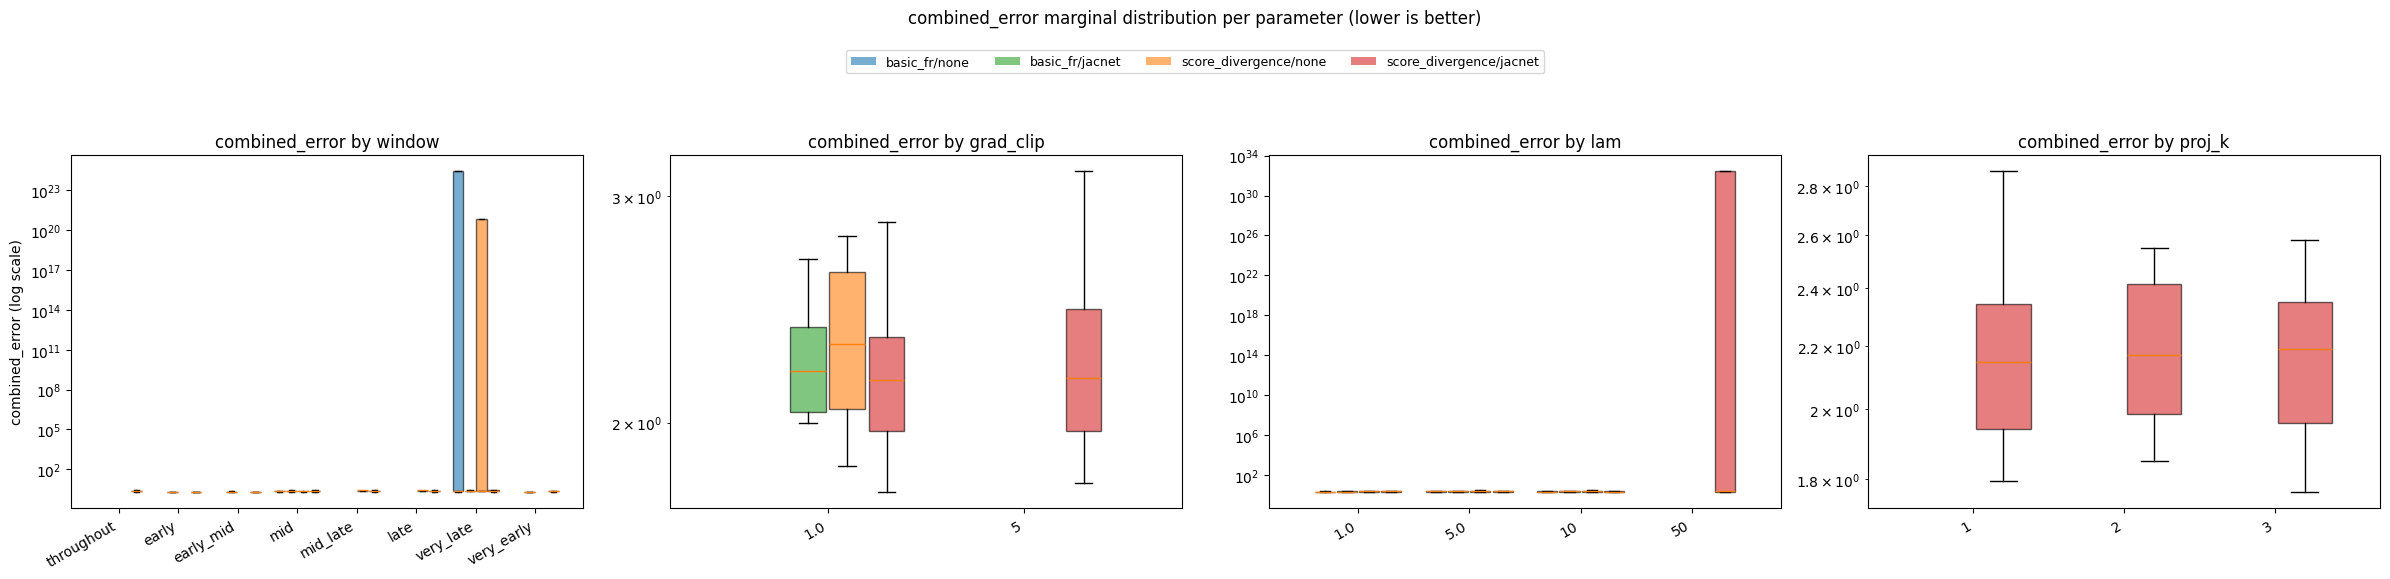

In [12]:
# Same (method, jacobian) -> color identity as the earlier diagnostic panel (blue/orange = "none"/unprojected,
# green/red = "jacnet"/projected) so color means the same thing everywhere in this notebook.
GROUP_COLORS = {
    ("basic_fr", "none"): "tab:blue",
    ("basic_fr", "jacnet"): "tab:green",
    ("score_divergence", "none"): "tab:orange",
    ("score_divergence", "jacnet"): "tab:red",
}
GROUPS = list(GROUP_COLORS.keys())
JACNET_GROUPS = [g for g in GROUPS if g[1] == "jacnet"]

def grouped_boxplot(ax, param_col, values, data, groups):
    width = 0.8 / len(groups)
    for gi, (method, jacobian) in enumerate(groups):
        sub = data[(data.method == method) & (data.jacobian == jacobian)]
        positions = [i + (gi - (len(groups) - 1) / 2) * width for i in range(len(values))]
        box_data = [sub.loc[sub[param_col] == v, "combined_error"].values for v in values]
        bp = ax.boxplot(box_data, positions=positions, widths=width * 0.9, patch_artist=True, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(GROUP_COLORS[(method, jacobian)])
            patch.set_alpha(0.6)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(v) for v in values], rotation=30, ha="right")
    ax.set_yscale("log")
    ax.set_title(f"combined_error by {param_col}")

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (param_col, values) in zip(axes[:3], PARAM_COLS.items()):
    grouped_boxplot(ax, param_col, values, guided, GROUPS)
grouped_boxplot(axes[3], "proj_k", config["proj_ks"], jacnet_only, JACNET_GROUPS)
axes[0].set_ylabel("combined_error (log scale)")

legend_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, alpha=0.6) for c in GROUP_COLORS.values()]
legend_labels = [f"{m}/{j}" for m, j in GROUPS]
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("combined_error marginal distribution per parameter (lower is better)", y=1.15)
plt.tight_layout()
plt.savefig("checkpoints/param_marginals.png", dpi=120, bbox_inches="tight")
plt.show()

## Scatterplots from a few different angles

"different angles" means different 2D plane cuts through that space
entries `M[r1,c1]` vs `M[r2,c2]` against each other. Silver = generated samples, colored = training atoms. Each
row is a different plane cut; each column is a different condition (unguided + each method/jacobian's best
config).

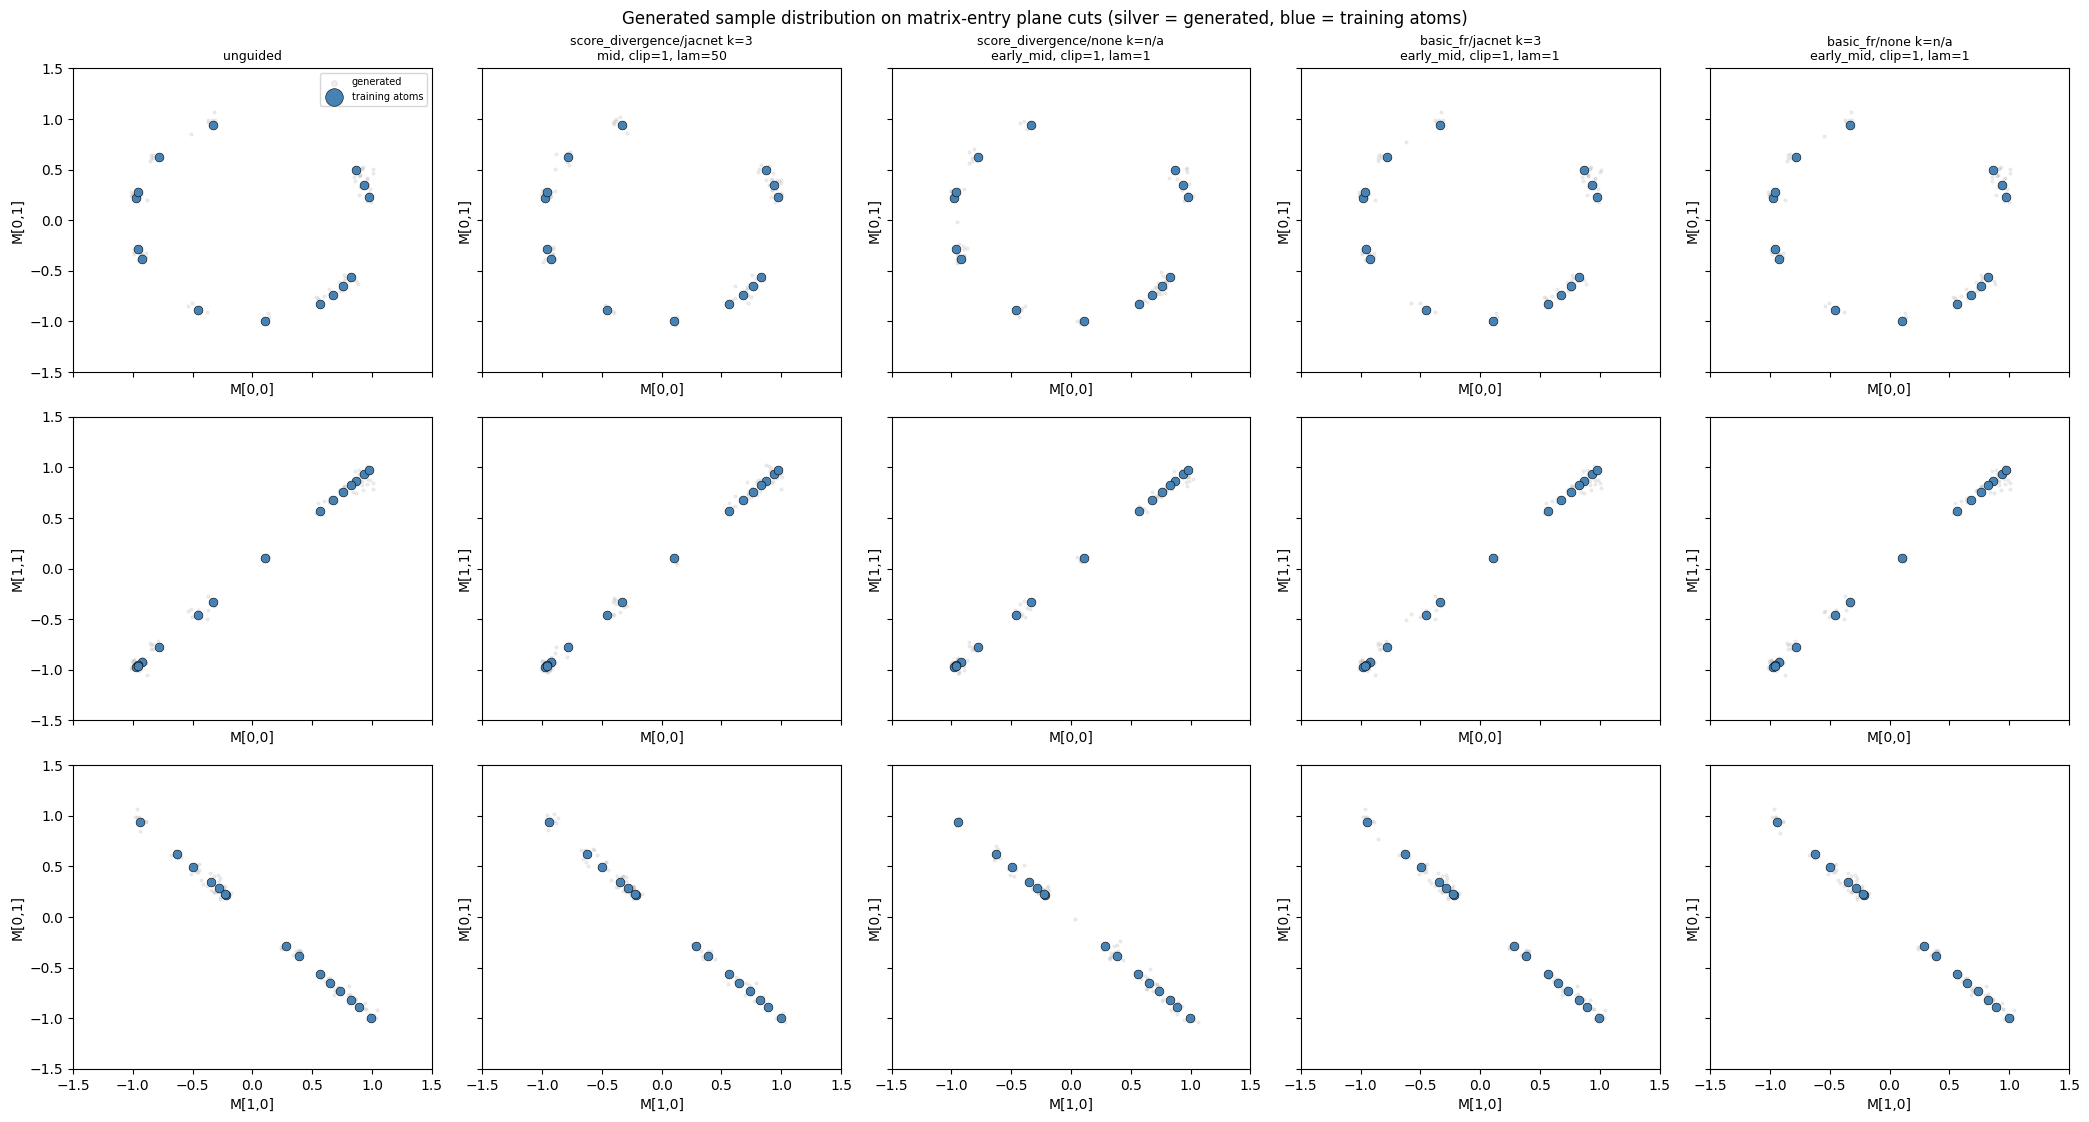

In [13]:
pairs = [(0, 0, 0, 1), (0, 0, 1, 1), (1, 0, 0, 1)]   # (r1, c1, r2, c2) -- matches preliminary/fisher_rao_guidance_so(n).ipynb
S_tgt = X_target.reshape(-1, n, n).cpu()
picks = [("unguided", "none", "n/a", "n/a", 0.0, 0.0)]
for _, r in best_per_method.iterrows():
    picks.append((r["method"], r["jacobian"], r["proj_k"], r["window"], r["grad_clip"], r["lam"]))

fig, axes = plt.subplots(len(pairs), len(picks), figsize=(4.2 * len(picks), 3.8 * len(pairs)), sharex=True, sharey=True)
for col, key in enumerate(picks):
    X = samples_cache[key]
    xg = X.reshape(-1, n, n).cpu().numpy()
    method, jacobian, proj_k, window, gc, lam = key
    title = "unguided" if method == "unguided" else f"{method}/{jacobian} k={proj_k}\n{window}, clip={gc:g}, lam={lam:g}"
    for row, (r1, c1, r2, c2) in enumerate(pairs):
        ax = axes[row, col]
        ax.scatter(xg[:, r1, c1], xg[:, r2, c2], s=4, alpha=0.25, color="silver",
                   label="generated" if row == 0 and col == 0 else None)
        ax.scatter(S_tgt[:, r1, c1].numpy(), S_tgt[:, r2, c2].numpy(), s=40, c="steelblue",
                   zorder=5, edgecolors="black", linewidths=0.4,
                   label="training atoms" if row == 0 and col == 0 else None)
        ax.set(xlabel=f"M[{r1},{c1}]", ylabel=f"M[{r2},{c2}]", xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
        if row == 0:
            ax.set_title(title, fontsize=9)
axes[0, 0].legend(markerscale=2, fontsize=7, loc="upper right")
plt.suptitle("Generated sample distribution on matrix-entry plane cuts (silver = generated, blue = training atoms)")
plt.tight_layout(); plt.savefig("checkpoints/fr_landing_scatter.png", dpi=120); plt.show()